# First, read in CERES EBAF data

In [1]:
# Import necessary modules
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the CERES EBAF data
# Update the filepath to your specific CERES file
data_path = '/pl/active/kaygroup/CERES-EBAF/CERES_EBAF_Edition4.2.1_200003-202509.nc'
ds = xr.open_dataset(data_path)

In [7]:
# Explore file structure
print("Dataset variables:")
print(ds.data_vars)
print("\nDataset dimensions:")
print(ds.dims)
print("\nDataset coordinates:")
print(ds.coords)
print("\nFull dataset info:")
print(ds)

# View specific variable information
# Replace 'variable_name' with actual CERES variable name
variable_name_1 = 'toa_sw_all_mon'  # Example CERES variable
print(f"\n Variable: {variable_name_1}")
print(ds[variable_name_1].attrs)

variable_name_2 = 'solar_mon'  # Incident solar
print(f"\n Variable: {variable_name_2}")
print(ds[variable_name_2].attrs)

variable_name_3 = 'solar_clim'  # Incident solar
print(f"\n Variable: {variable_name_3}")
print(ds[variable_name_3].attrs)

variable_name_4 = 'gtoa_sw_all_mon'  # Global mean TOA SW all sky
print(f"\n Variable: {variable_name_4}")
print(ds[variable_name_4].attrs)

Dataset variables:
Data variables:
    climatology_bounds             (ctime, sc) int32 ...
    toa_sw_all_mon                 (time, lat, lon) float32 ...
    toa_lw_all_mon                 (time, lat, lon) float32 139.5 ... 208.3
    toa_net_all_mon                (time, lat, lon) float32 ...
    toa_sw_clr_c_mon               (time, lat, lon) float32 ...
    toa_lw_clr_c_mon               (time, lat, lon) float32 ...
    toa_net_clr_c_mon              (time, lat, lon) float32 ...
    toa_sw_clr_t_mon               (time, lat, lon) float32 ...
    toa_lw_clr_t_mon               (time, lat, lon) float32 ...
    toa_net_clr_t_mon              (time, lat, lon) float32 ...
    toa_cre_sw_mon                 (time, lat, lon) float32 ...
    toa_cre_lw_mon                 (time, lat, lon) float32 ...
    toa_cre_net_mon                (time, lat, lon) float32 ...
    solar_mon                      (time, lat, lon) float32 ...
    cldarea_total_daynight_mon     (time, lat, lon) float32 ...


## Let's look at time series that compares absorbed shortwave radiation with outgoing longwave radiation over the CERES record

The absorbed shortwave flux can be computed as: ASR = SW_incident - SW_reflected

Relevant CERES variables:

    (1) toa_sw_all_mon - Top of The Atmosphere Shortwave Flux, All-Sky conditions, Monthly Means [W m-2]
    
    (2) toa_lw_all_mon - Top of The Atmosphere Longwave Flux, All-Sky conditions, Monthly Means [W m-2]
    
    (3)      solar_mon - Incoming Solar Flux, Monthly Means [W m-2]

In [8]:
# Compute the abosrbed solar radiation using monthly means
ASR = ds.solar_mon - ds.toa_sw_all_mon
ASR_g = ds.gsolar_mon - ds.gtoa_sw_all_mon  # using the global averages

# Grab the time vector
t = ds.time
t_g = ds.ctime  # integer values for now


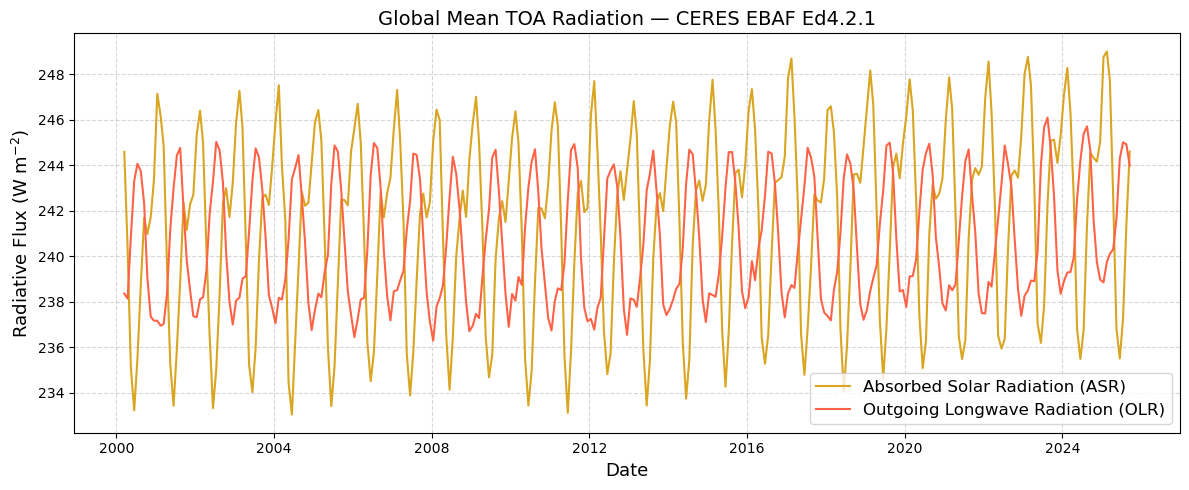

In [9]:
# Create a time series comparing ASR with outgoing LW
#
# Both ASR and toa_lw_all_mon are 3D arrays: (time x lat x lon)
# We need to collapse lat and lon into a single global mean value at each time step.
#
# MATLAB analogy: this is like doing squeeze(nanmean(nanmean(data, 2), 3))
# but here we use area-weighted averaging so high-latitude grid cells
# (which cover less area) don't get the same weight as tropical cells.
#
# The area weight for each grid cell is proportional to cos(latitude).
# Near the equator cos(lat) ≈ 1 (large area), near the poles cos(lat) ≈ 0 (tiny area).

# --- Step 1: Compute area weights ---
weights = np.cos(np.deg2rad(ds['lat']))  # 1D array of weights, one per latitude

# --- Step 2: Compute global weighted mean at each time step ---
# .weighted(weights) tells xarray to use cosine weighting along lat
# .mean(dim=['lat', 'lon']) collapses the spatial dimensions
# Result is a 1D time series (like a 1 x N vector in MATLAB)
ASR_global  = ASR.weighted(weights).mean(dim=['lat', 'lon'])
OLR_global  = ds['toa_lw_all_mon'].weighted(weights).mean(dim=['lat', 'lon'])

# --- Step 3: Plot ---
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(t.values, ASR_global.values, color='goldenrod', linewidth=1.5, label='Absorbed Solar Radiation (ASR)')
ax.plot(t.values, OLR_global.values, color='tomato',    linewidth=1.5, label='Outgoing Longwave Radiation (OLR)')

ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Radiative Flux (W m$^{-2}$)', fontsize=13)
ax.set_title('Global Mean TOA Radiation — CERES EBAF Ed4.2.1', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

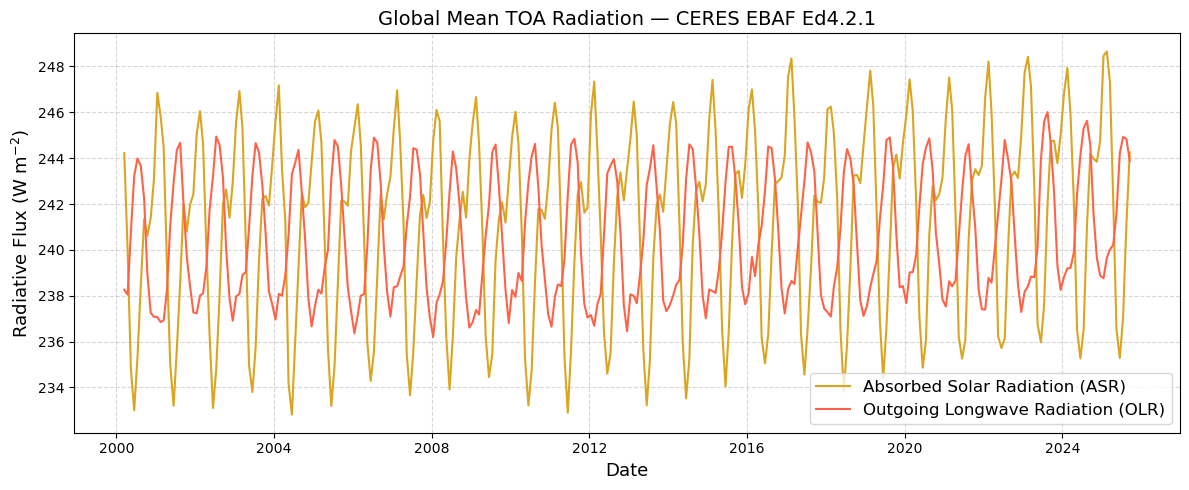

In [17]:
# --- Try plotting the internally computed global means ---
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(t.values, ASR_g.values, color='goldenrod', linewidth=1.5, label='Absorbed Solar Radiation (ASR)')
ax.plot(t.values, ds['gtoa_lw_all_mon'].values, color='tomato',    linewidth=1.5, label='Outgoing Longwave Radiation (OLR)')

ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Radiative Flux (W m$^{-2}$)', fontsize=13)
ax.set_title('Global Mean TOA Radiation — CERES EBAF Ed4.2.1', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

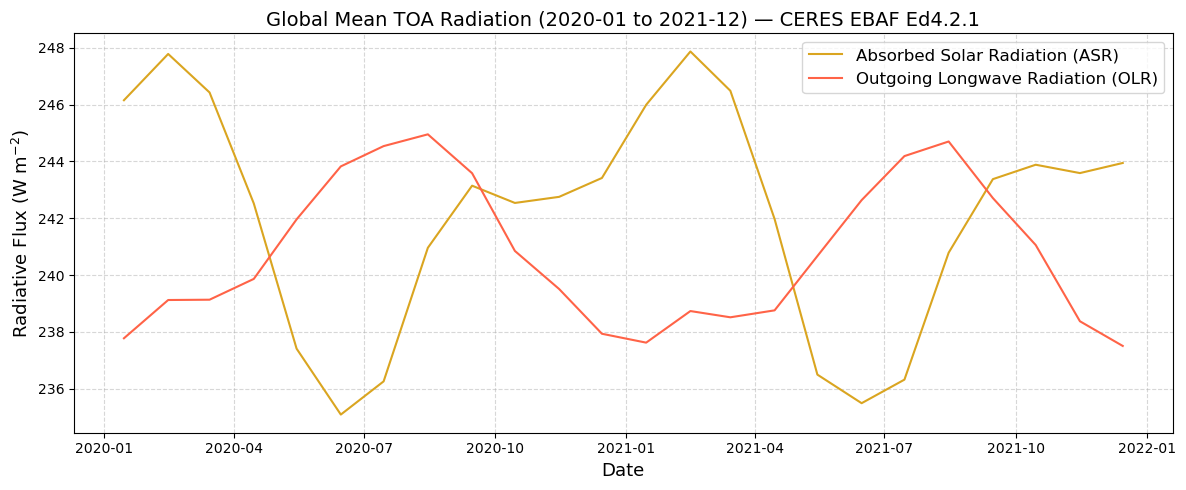

In [18]:
# Plot a subset of the time series
#
# MATLAB analogy: this is like logical indexing on a time vector, e.g.:
#   idx = t >= datenum('2020-01-01') & t <= datenum('2021-12-31');
#   plot(t(idx), data(idx))
#
# In xarray, .sel(time=slice('start', 'end')) does the same thing cleanly.
# You just pass date strings — no need to convert to datenums.

# --- Define your time range here ---
start_date = '2020-01'   # format: 'YYYY-MM'
end_date   = '2021-12'   # format: 'YYYY-MM'

# --- Subset each global mean time series using .sel() ---
ASR_subset = ASR_global.sel(time=slice(start_date, end_date))
OLR_subset = OLR_global.sel(time=slice(start_date, end_date))

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(ASR_subset.time.values, ASR_subset.values, color='goldenrod', linewidth=1.5, label='Absorbed Solar Radiation (ASR)')
ax.plot(OLR_subset.time.values, OLR_subset.values, color='tomato',    linewidth=1.5, label='Outgoing Longwave Radiation (OLR)')

ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Radiative Flux (W m$^{-2}$)', fontsize=13)
ax.set_title(f'Global Mean TOA Radiation ({start_date} to {end_date}) — CERES EBAF Ed4.2.1', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

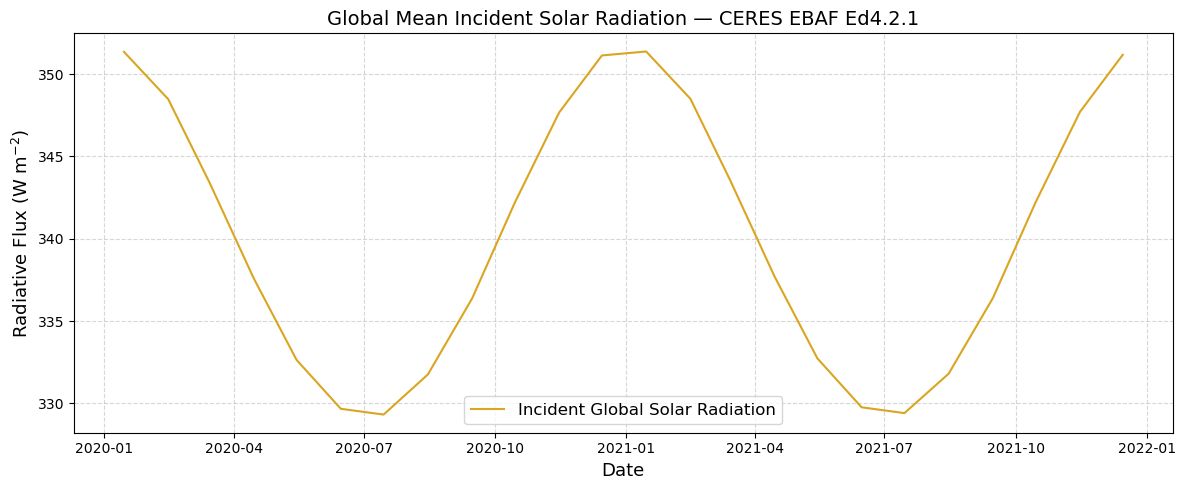

In [20]:
# Compute the global mean incident solar flux
# Because of our orbital obliquity, one hemispere should have more insolation in the summer 
# compared with the other

# --- Define your time range here ---
start_date = '2020-01'   # format: 'YYYY-MM'
end_date   = '2021-12'   # format: 'YYYY-MM'

# --- Subset each global mean time series using .sel() ---
incident_sol_g_subset = ds.gsolar_mon.sel(time=slice(start_date, end_date))

# --- Step 3: Plot ---
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(incident_sol_g_subset.time.values, incident_sol_g_subset, color='goldenrod', linewidth=1.5, label='Incident Global Solar Radiation')

ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Radiative Flux (W m$^{-2}$)', fontsize=13)
ax.set_title('Global Mean Incident Solar Radiation — CERES EBAF Ed4.2.1', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Let's investigate the periods of negative EEI in the CERES data record